In [6]:
!pip install xgboost


# Heart Disease Prediction Model

In [7]:
#Preparing tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#we want to see plot inside our notebook
import seaborn as sns

#models from scikitlearn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
#model evaluations
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import precision_score,recall_score,f1_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_curve

In [8]:
# Loading data

In [9]:
df=pd.read_csv("heart.csv")
df.shape

(303, 14)

# Data exploration (Exploratory data analysis or Eda)
#The goal is to find more about data
#What questions are we trying to solve and how we treat different types?
#Whats missing from data and how do we deal with it?
#What are outliers and why should we care about them?
#How can we add,change or remove features?

In [10]:
#lets find out how many of each class are there i.e 0 and 1
df[df.target==0]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
165,67,1,0,160,286,0,0,108,1,1.5,1,3,2,0
166,67,1,0,120,229,0,0,129,1,2.6,1,2,3,0
167,62,0,0,140,268,0,0,160,0,3.6,0,2,2,0
168,63,1,0,130,254,0,0,147,0,1.4,1,1,3,0
169,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


<Axes: xlabel='target'>

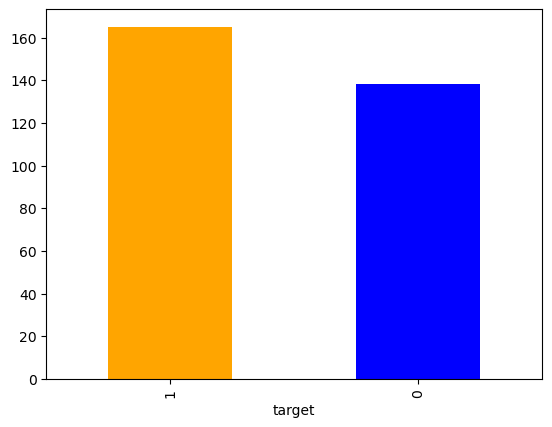

In [11]:
df['target'].value_counts().plot(kind="bar",color=["orange","blue"])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [13]:
#missing values
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [14]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


#comparing columns Heart Disease frequency vs sex  -[EDA]


In [15]:
df.sex.value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [16]:
pd.crosstab(df.target,df.sex)
#From here we can say that 96 out of 72 womens i.e 75% women have chances of heart disease


sex,0,1
target,,
0,24,114
1,72,93


(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

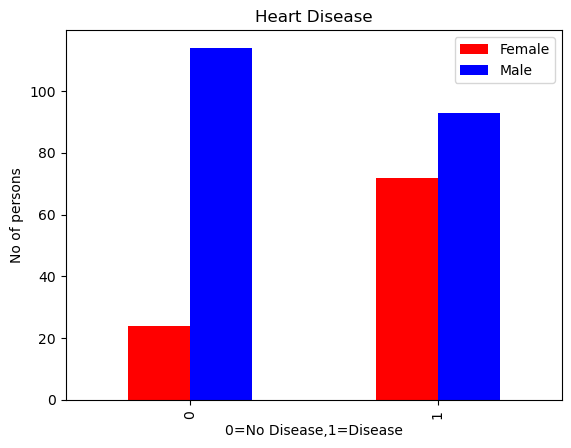

In [17]:
pd.crosstab(df.target,df.sex).plot(kind="bar",color=["red","blue"])
plt.title("Heart Disease")
plt.xlabel("0=No Disease,1=Disease")
plt.ylabel("No of persons")
plt.legend(["Female","Male"])
plt.xticks()

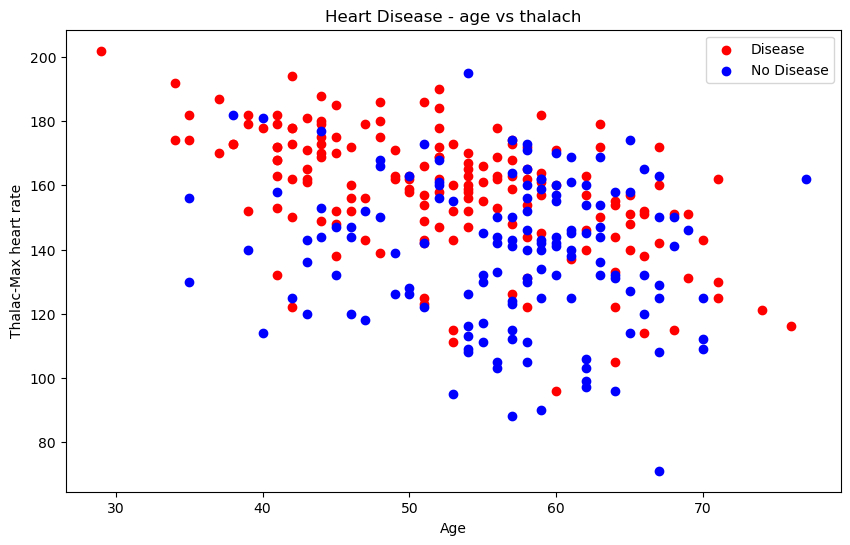

In [18]:
#age vs max heart rate(thalac)
plt.figure(figsize=(10,6))

plt.scatter(df.age[df.target==1],df.thalach[df.target==1],c="red")
plt.scatter(df.age[df.target==0],df.thalach[df.target==0],c="blue")
plt.title("Heart Disease - age vs thalach")
plt.xlabel("Age")
plt.ylabel("Thalac-Max heart rate")
plt.legend(["Disease","No Disease"])

<Axes: ylabel='Frequency'>

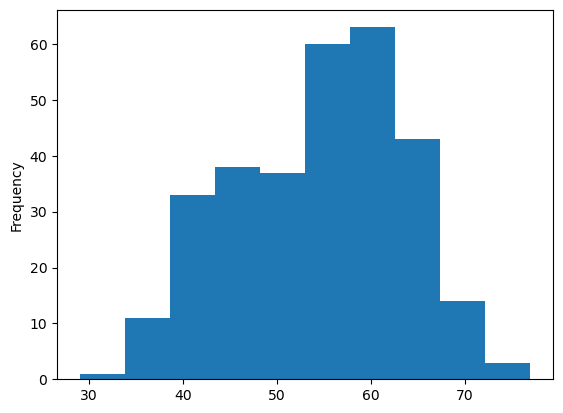

In [19]:
#distribution of age col
df.age.plot(kind="hist")

<Axes: xlabel='cp'>

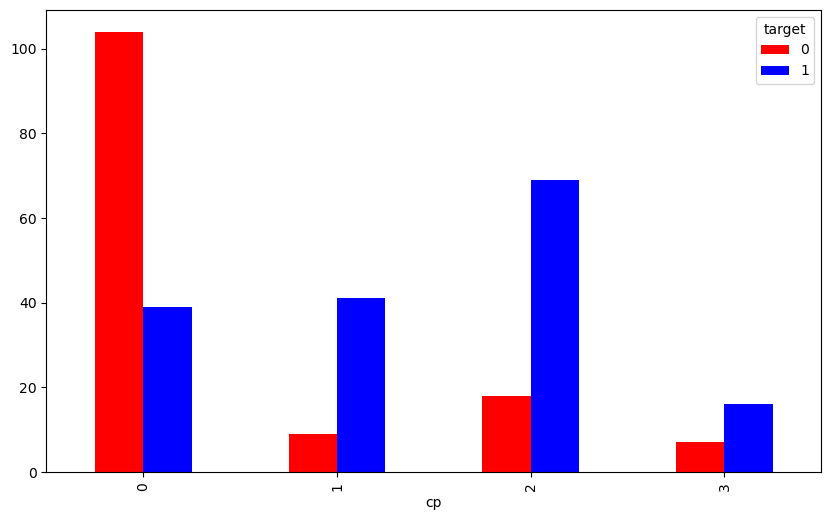

In [20]:
#HeartDisease vs cp
pd.crosstab(df.cp,df.target).plot(kind="bar",figsize=(10,6),color=["red","blue"])

In [21]:
#building a correlation matrixs
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


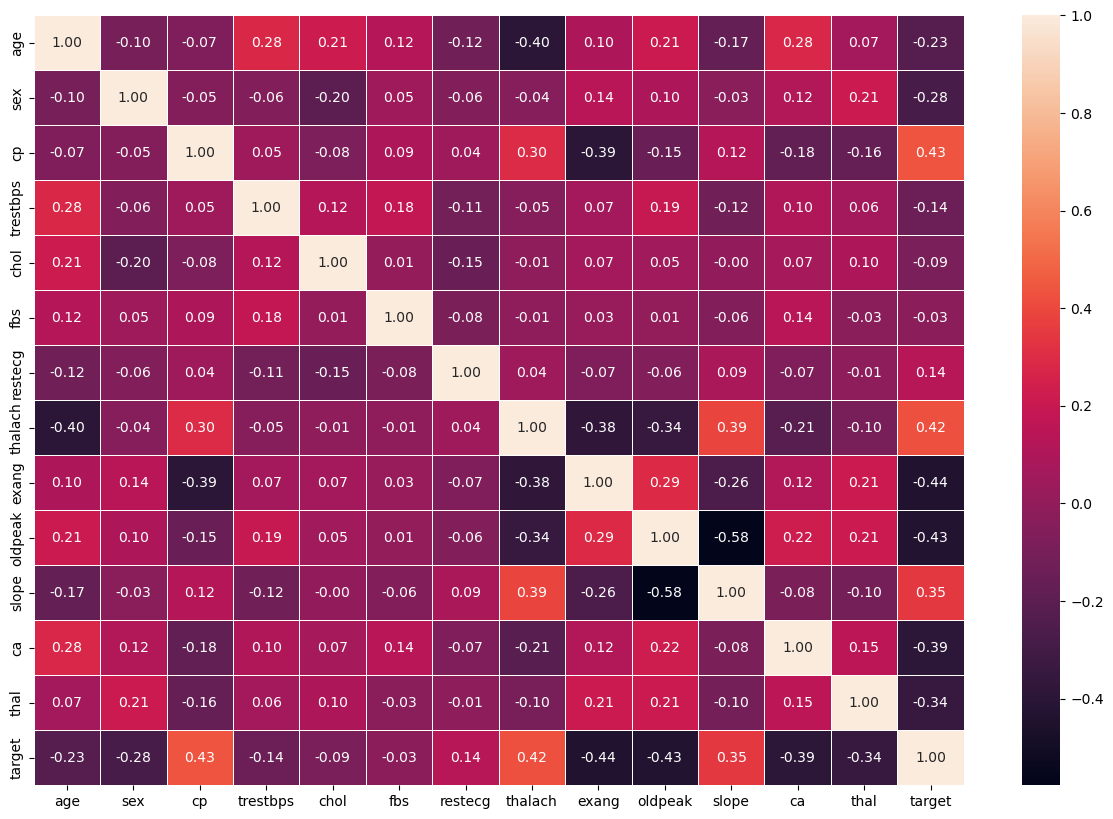

In [22]:
#making correlation matrix a little readable
corr_matrix=df.corr()
fig,ax=plt.subplots(figsize=(15,10))
ax=sns.heatmap(corr_matrix,annot=True,linewidths=0.5,fmt=".2f")

# Data Cleaning

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16964\3017382700.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df.values, labels=df.columns)


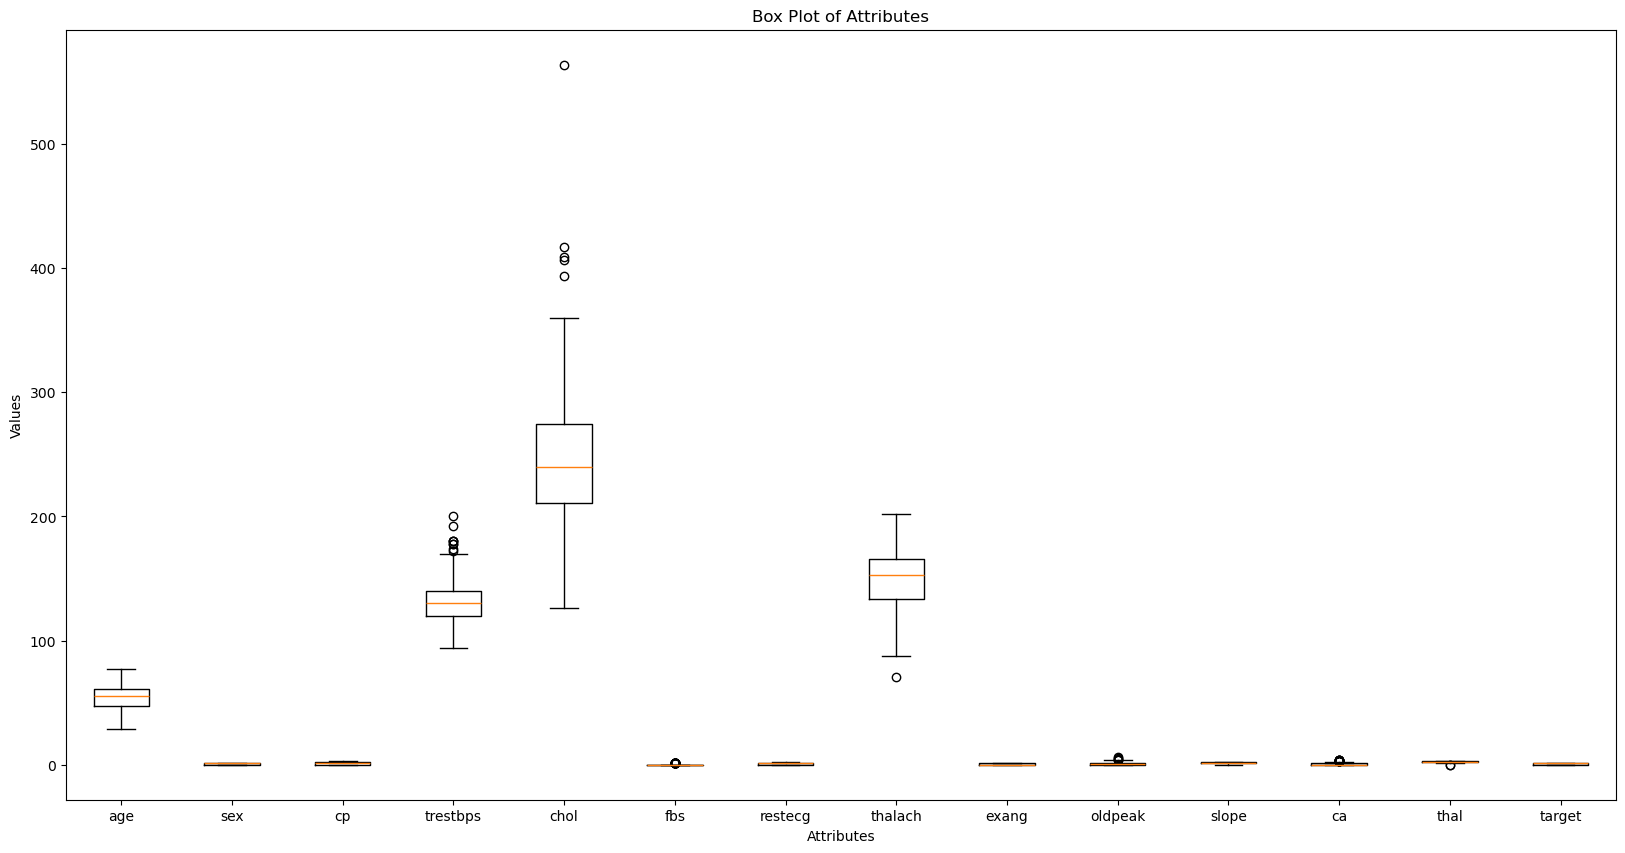

In [23]:
#checking for outliers
#Outliers-Data that deviates from other points too much
plt.figure(figsize=(20, 10))
plt.boxplot(df.values, labels=df.columns)
plt.title("Box Plot of Attributes")
plt.xlabel("Attributes")
plt.ylabel("Values")
plt.show()




In [24]:
#Function for removing outliers
def outlier(df,col):
    # Calculate the IQR for the pregnancies column
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define upper and lower bounds to identify outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Replace outliers with capped values
    df[col] = df[col].apply(lambda x: min(upper_bound, max(lower_bound, x)))

In [25]:
#Removing outliers
outlier(df,'chol')
outlier(df,'trestbps')
outlier(df,'fbs')
outlier(df,'thal')
outlier(df,'thalach')
outlier(df,'ca')
df=df.drop('exang',axis=1)
df=df.drop('oldpeak',axis=1)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16964\3391002344.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df.values, labels=df.columns)


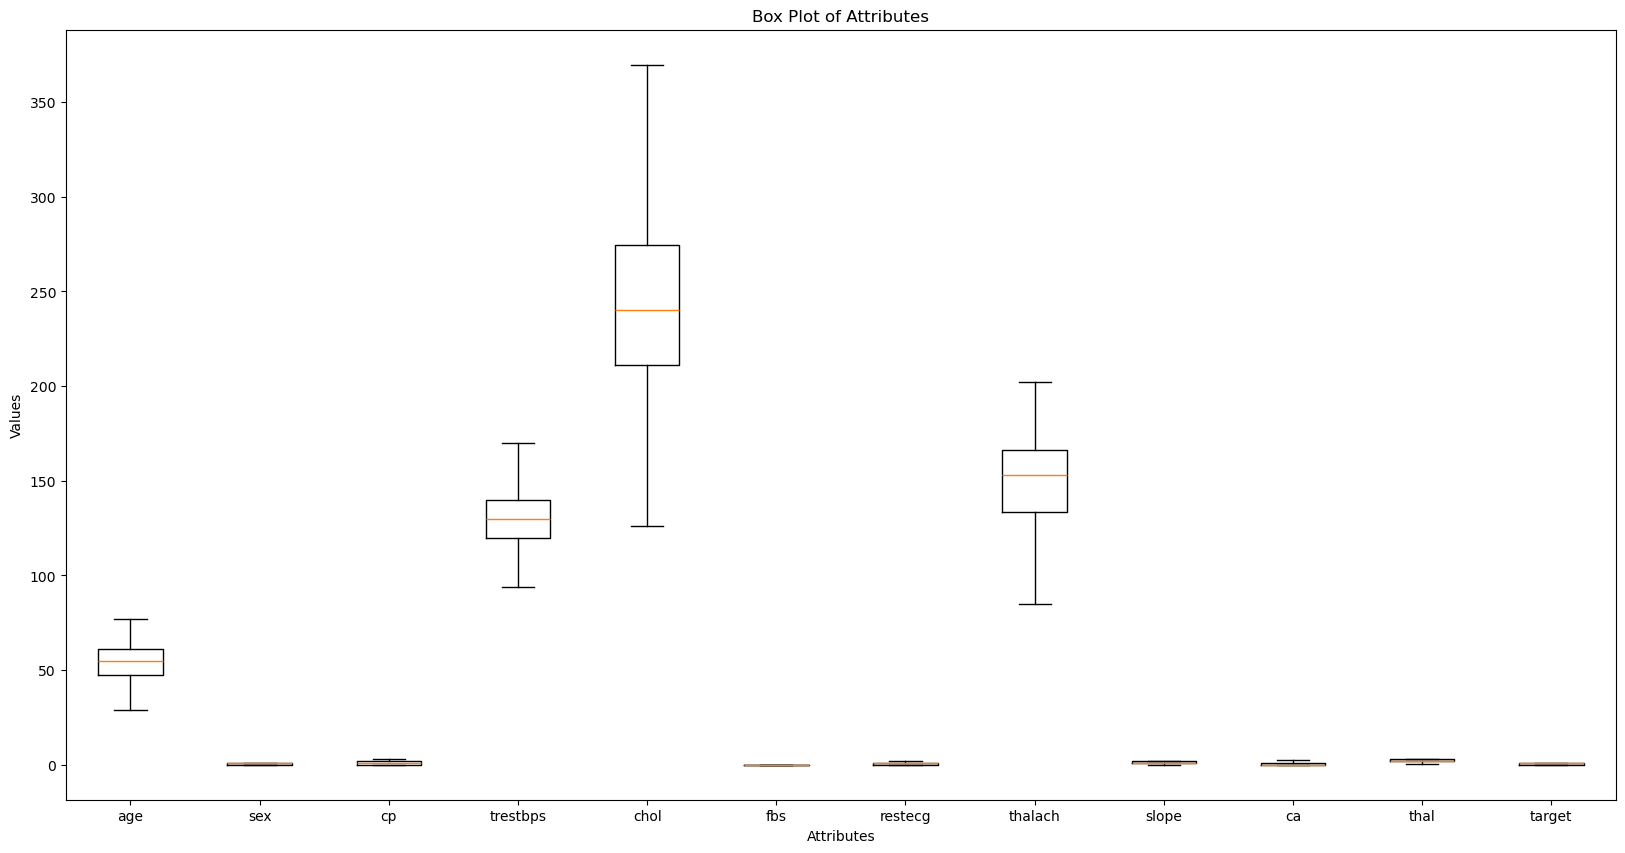

In [26]:
#boxplots after removing outliers
plt.figure(figsize=(20, 10))
plt.boxplot(df.values, labels=df.columns)
plt.title("Box Plot of Attributes")
plt.xlabel("Attributes")
plt.ylabel("Values")
plt.show()



# Modelling the data

In [27]:
#split data into x and y
x=df.drop("target",axis=1)
y=df["target"]

In [28]:
#train and test
np.random.seed(42)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [29]:
#Choosing a ml model
models={"Logistic":LogisticRegression(),"KNN":KNeighborsClassifier(),"RandomForest":RandomForestClassifier(),"SVM":SVC(),"D_tree":DecisionTreeClassifier()}

def fit_and_score(models,x_train,x_test,y_train,y_test):
    np.random.seed(42)
    model_scores={}
    for name,model in models.items():
        model.fit(x_train,y_train)
        model_scores[name]=model.score(x_test,y_test)
    return model_scores

In [30]:
model_scores=fit_and_score(models=models,x_train=x_train,x_test=x_test,y_train=y_train,y_test=y_test)
model_scores

e:\Anaconda3\envs\pytorch_env\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic': 0.8852459016393442,
 'KNN': 0.7049180327868853,
 'RandomForest': 0.8360655737704918,
 'SVM': 0.7049180327868853,
 'D_tree': 0.8032786885245902}

<Axes: >

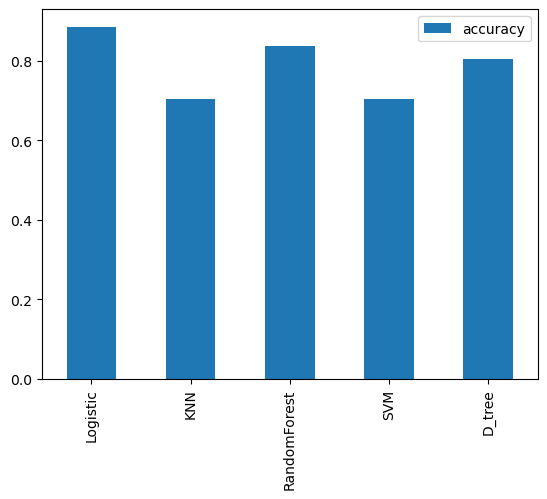

In [31]:
#Comparing models visually
model_compare=pd.DataFrame(model_scores,index=["accuracy"])
model_compare.T.plot(kind='bar')

# Models first prediction are not always good
#What we will do
1)HyperParameter tuning
2)Feature importance
3)Confusion matrix
4)Cross-validation
5)Precision
6)Recall
7)F1 score
8)Classification report
9)Roc curve
10)Area under the curve(AUC)

# Hyperparameter tuning

In [32]:
#tuning knn by hand
train_scores=[]
test_scores=[]

#create a list of different value of n_neighbors
neighbors=range(1,21)
#setup knn instance
knn=KNeighborsClassifier()

#loop thru different n_neighbors
for i in neighbors:
    knn.set_params(n_neighbors=i)

    #fit the algo
    knn.fit(x_train,y_train)
    #updating the training scores list
    train_scores.append(knn.score(x_train,y_train))
    #updating test scores
    test_scores.append(knn.score(x_test,y_test))

In [33]:
train_scores,test_scores

([1.0,
  0.8140495867768595,
  0.7768595041322314,
  0.7396694214876033,
  0.756198347107438,
  0.7520661157024794,
  0.7479338842975206,
  0.7272727272727273,
  0.71900826446281,
  0.7024793388429752,
  0.7272727272727273,
  0.7066115702479339,
  0.7024793388429752,
  0.6942148760330579,
  0.6818181818181818,
  0.6776859504132231,
  0.6776859504132231,
  0.6570247933884298,
  0.6942148760330579,
  0.6611570247933884],
 [0.639344262295082,
  0.6229508196721312,
  0.6557377049180327,
  0.6721311475409836,
  0.7049180327868853,
  0.7213114754098361,
  0.7049180327868853,
  0.6885245901639344,
  0.6885245901639344,
  0.7049180327868853,
  0.7540983606557377,
  0.7213114754098361,
  0.7377049180327869,
  0.7377049180327869,
  0.7377049180327869,
  0.7377049180327869,
  0.7049180327868853,
  0.7049180327868853,
  0.7049180327868853,
  0.6721311475409836])

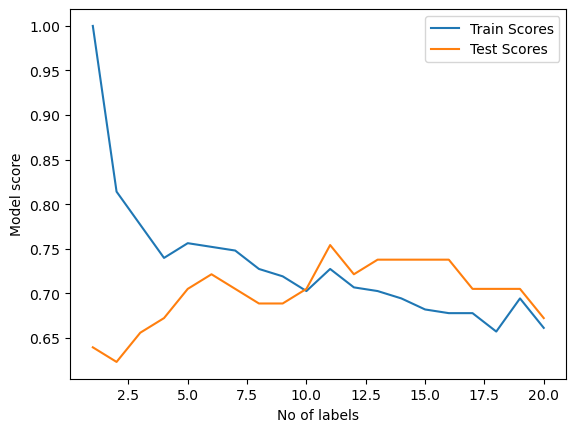

In [34]:
plt.plot(neighbors,train_scores,label="Train Scores")
plt.plot(neighbors,test_scores,label="Test Scores")
plt.xlabel("No of labels")
plt.ylabel("Model score")
plt.legend()

In [35]:
print(f"Max knn score on test data is {max(test_scores)*100}")

Max knn score on test data is 75.40983606557377


# Hyperparameter tuning by GridSearchCv


In [36]:
#Tuning logistic regression by randomizedsearchcv
#creating a hyperparameter grid for logistic regression
log_reg_grid = {
    'C': np.logspace(-6, 6, 100),
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'] ,
    'max_iter': [1000]
}
#creating a hyperparameter grid for randomforest
rf_grid={"n_estimators":np.arange(10,1000,50),"max_depth":[None,3,5,10],
        "min_samples_split":np.arange(2,20,2),
         "min_samples_leaf":np.arange(1,20,2)
        }

In [37]:
#tunning logistic regrssion
np.random.seed(42)

gs_log_reg = GridSearchCV(
    LogisticRegression(),
    param_grid=log_reg_grid,
    cv=5,
    verbose=True,
    n_jobs=-1,

)
#fitting random hyperparametr search model
gs_log_reg.fit(x_train,y_train)


Fitting 5 folds for each of 500 candidates, totalling 2500 fits


,estimator,LogisticRegression()
,param_grid,"{'C': array([1.0000...00000000e+06]), 'max_iter': [1000], 'solver': ['newton-cg', 'lbfgs', ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [38]:
gs_log_reg.best_params_

{'C': np.float64(8.111308307896872), 'max_iter': 1000, 'solver': 'liblinear'}

In [39]:
gs_log_reg.score(x_test,y_test)

0.8688524590163934

In [40]:
#tuning random forest now

np.random.seed(42)

rs_rf=RandomizedSearchCV(RandomForestClassifier(n_jobs=-1)
                              ,param_distributions=rf_grid
                              ,cv=5,n_iter=20,verbose=True)
#fitting random hyperparametr search model
rs_rf.fit(x_train,y_train)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,RandomForestC...ier(n_jobs=-1)
,param_distributions,"{'max_depth': [None, 3, ...], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), 'min_samples_split': array([ 2, 4..., 14, 16, 18]), 'n_estimators': array([ 10, ...60, 910, 960])}"
,n_iter,20
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [41]:
rs_rf.best_params_

{'n_estimators': np.int64(210),
 'min_samples_split': np.int64(4),
 'min_samples_leaf': np.int64(19),
 'max_depth': 3}

In [42]:
rs_rf.score(x_test,y_test)

0.9180327868852459

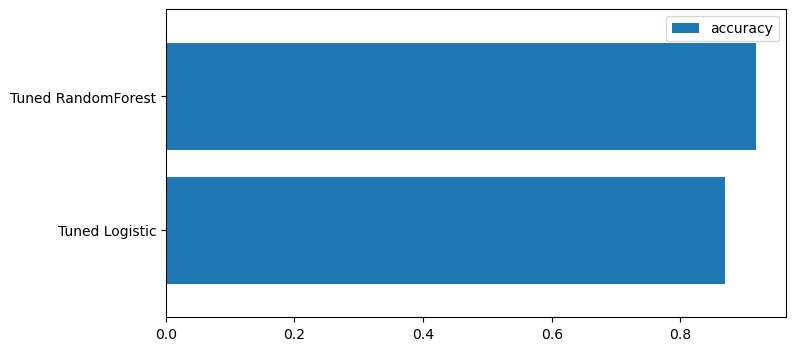

In [43]:
gs_log_reg.score(x_test,y_test),rs_rf.score(x_test,y_test)
#Comparing models visually
# Create a DataFrame for model comparison
model_compare = pd.DataFrame({"Tuned Logistic": gs_log_reg.score(x_test,y_test), "Tuned RandomForest": rs_rf.score(x_test,y_test)}, index=["accuracy"])

# Create a horizontal bar graph
ax = model_compare.T.plot(kind='barh', figsize=(8, 4), width=0.8, align='center')



# Evaluating our tuned ml classifier,beyond accuracy
1)Roc curve and auc curve
2)Confusion Matrix
3)Classification report
4)Precision
5)Recall
6)F1-score

# Evaluating RandomForest

In [44]:
#To make comparisons and evaluate our trained model first we need to make predictions
y_preds=rs_rf.predict(x_test)
y_preds

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

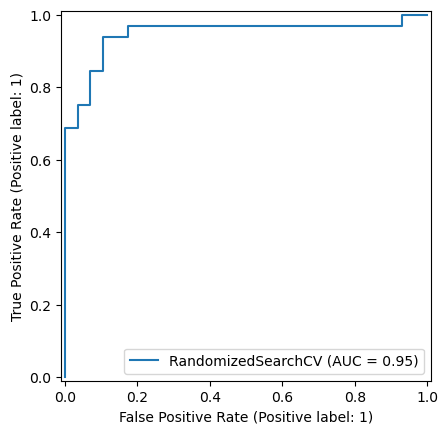

In [45]:
#plotting roc curve
svc_disp = RocCurveDisplay.from_estimator(rs_rf, x_test, y_test)

In [46]:
#confusion matrix
print(confusion_matrix(y_test,y_preds))

[[26  3]
 [ 2 30]]


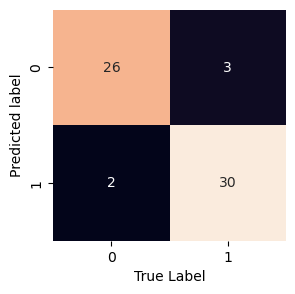

In [47]:
def plot_conf_mat(y_test,y_preds):
    fig,ax=plt.subplots(figsize=(3,3))
    ax=sns.heatmap(confusion_matrix(y_test,y_preds),annot=True,cbar=False)
    plt.xlabel("True Label")
    plt.ylabel("Predicted label")

plot_conf_mat(y_test,y_preds)

In [48]:
#Classification report and cross validated precision,recall and f1 score
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.93      0.90      0.91        29
           1       0.91      0.94      0.92        32

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



In [49]:
##calculate evaluation matrix using cross validation
rs_rf.score(x_test,y_test)

0.9180327868852459

In [50]:
rs_rf.predict(x_test)==gs_log_reg.predict(x_test)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True])

In [51]:
#cross validated accuracy
np.random.seed(4)
cv_acc=cross_val_score(rs_rf,x,y,cv=5,scoring='accuracy')
cv_acc

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits


array([0.83606557, 0.91803279, 0.75409836, 0.81666667, 0.75      ])

In [52]:
#mean accuracy
cv_acc=cv_acc.mean()

In [53]:
#cross validated precision
cv_pre=cross_val_score(rs_rf,x,y,cv=5,scoring='precision')
cv_pre

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits


array([0.78378378, 0.90625   , 0.86206897, 0.80555556, 0.7       ])

In [54]:
cv_pre=cv_pre.mean()

In [55]:
#cross validated recall
cv_recall=cross_val_score(rs_rf,x,y,cv=2,scoring='recall')
cv_recall

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits


array([0.92771084, 0.87804878])

In [56]:
cv_recall=cv_recall.mean()

In [57]:
#cross validated f1_score
cv_f1=cross_val_score(rs_rf,x,y,cv=2,scoring='f1')
cv_f1

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits


array([0.88505747, 0.78787879])

In [58]:
cv_f1=cv_f1.mean()

<Axes: title={'center': 'Cross validated metrics'}>

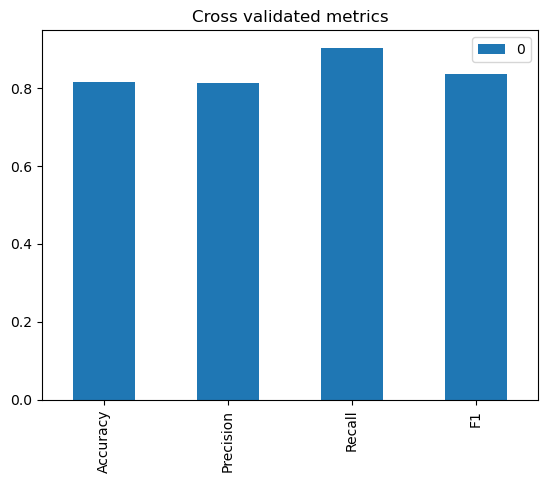

In [59]:
#visualizing
cv_metrics=pd.DataFrame({
    "Accuracy":cv_acc,
    "Precision":cv_pre,
    "Recall":cv_recall,
    "F1":cv_f1
},index=[0])
cv_metrics.T.plot.bar(title="Cross validated metrics")

# Evaluating Tuned Logistic Regression

In [60]:
#To make comparisons and evaluate our trained model first we need to make predictions
y_preds=gs_log_reg.predict(x_test)
y_preds

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

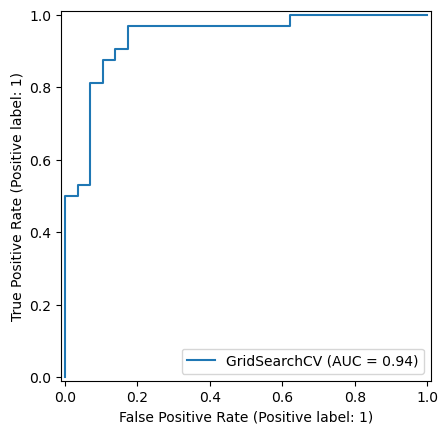

In [61]:
#plotting roc curve
gs_svc_disp = RocCurveDisplay.from_estimator(gs_log_reg, x_test, y_test)

In [62]:
#confusion matrix
print(confusion_matrix(y_test,y_preds))

[[26  3]
 [ 5 27]]


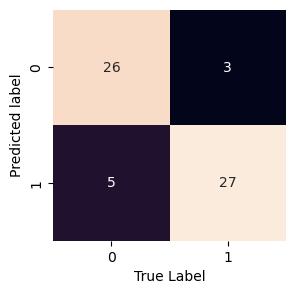

In [63]:
plot_conf_mat(y_test,y_preds)

In [64]:
#Classification report and cross validated precision,recall and f1 score
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



In [65]:
##calculate evaluation matrix using cross validation
gs_log_reg.score(x_test,y_test)

0.8688524590163934

In [66]:
#cross validated accuracy
np.random.seed(4)
cv_acc=cross_val_score(gs_log_reg,x,y,cv=2,scoring='accuracy')
cv_acc=cv_acc.mean()

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
Fitting 5 folds for each of 500 candidates, totalling 2500 fits


In [67]:
#cross validated precision
np.random.seed(4)
cv_pre=cross_val_score(gs_log_reg,x,y,cv=2,scoring='precision')
cv_pre=cv_pre.mean()

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
Fitting 5 folds for each of 500 candidates, totalling 2500 fits


In [68]:
#cross validated recall
np.random.seed(4)
cv_re=cross_val_score(gs_log_reg,x,y,cv=2,scoring='recall')
cv_re=cv_re.mean()

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
Fitting 5 folds for each of 500 candidates, totalling 2500 fits


In [69]:
#cross validated recall
np.random.seed(4)
cv_f1=cross_val_score(gs_log_reg,x,y,cv=2,scoring='f1')
cv_f1=cv_f1.mean()

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
Fitting 5 folds for each of 500 candidates, totalling 2500 fits


<Axes: title={'center': 'Cross validated metrics for Logistic'}>

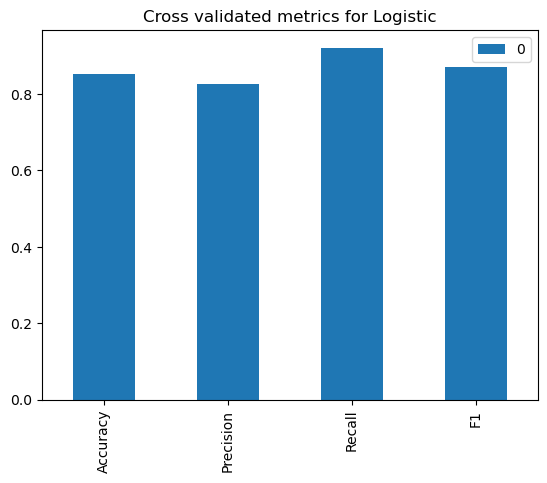

In [70]:
#visualizing
cv_metrics=pd.DataFrame({
    "Accuracy":cv_acc,
    "Precision":cv_pre,
    "Recall":cv_re,
    "F1":cv_f1
},index=[0])
cv_metrics.T.plot.bar(title="Cross validated metrics for Logistic")

# Feature Importance

In [71]:
gs_log_reg.best_estimator_.coef_

array([[ 0.011074  , -1.88508066,  0.88273858, -0.0228718 , -0.00748268,
         0.        ,  0.32338572,  0.03333987,  1.36448053, -1.23677136,
        -1.01842352]])

In [72]:
#match coefs of features to colms
feature_dict=dict(zip(df.columns,list(gs_log_reg.best_estimator_.coef_[0])))
feature_dict

{'age': np.float64(0.01107399914785068),
 'sex': np.float64(-1.8850806571899954),
 'cp': np.float64(0.8827385778329664),
 'trestbps': np.float64(-0.02287179774998105),
 'chol': np.float64(-0.007482675242020662),
 'fbs': np.float64(0.0),
 'restecg': np.float64(0.32338572476410016),
 'thalach': np.float64(0.033339872799689495),
 'slope': np.float64(1.364480533492904),
 'ca': np.float64(-1.2367713645322744),
 'thal': np.float64(-1.0184235202894834)}

<Axes: title={'center': 'Feature importance'}>

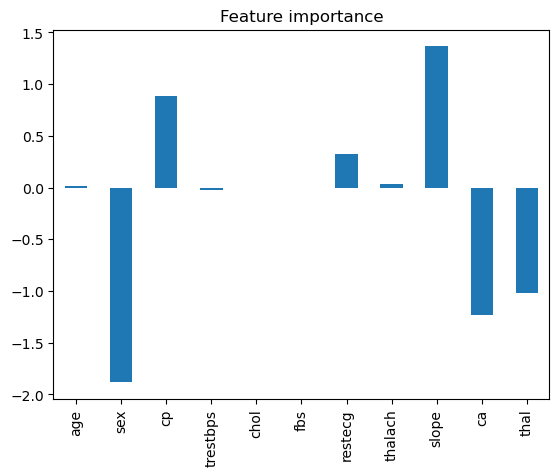

In [73]:
#visualize feature importance
feature_df=pd.DataFrame(feature_dict,index=[0])
feature_df.T.plot.bar(title="Feature importance",legend=False)

In [74]:
import pickle
pickle.dump(gs_log_reg,open("heartDiseaseMlUpdated.pkl","wb"))

In [75]:
x_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,slope,ca,thal
179,57,1,0,150.0,276.00,0.0,0,112.0,1,1.0,1.0
228,59,1,3,170.0,288.00,0.0,0,159.0,1,0.0,3.0
111,57,1,2,150.0,126.00,0.0,1,173.0,2,1.0,3.0
246,56,0,0,134.0,369.75,0.0,0,150.0,1,2.0,3.0
60,71,0,2,110.0,265.00,0.0,0,130.0,2,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...
249,69,1,2,140.0,254.00,0.0,0,146.0,1,2.5,3.0
104,50,1,2,129.0,196.00,0.0,1,163.0,2,0.0,2.0
300,68,1,0,144.0,193.00,0.0,1,141.0,1,2.0,3.0
193,60,1,0,145.0,282.00,0.0,0,142.0,1,2.0,3.0
